In [5]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import datetime as dt
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from scipy import stats as sps
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, _tree, plot_tree
from xgboost import XGBClassifier, XGBRegressor


In [40]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

PCA 保留 131 個主成分


---
---

In [41]:
def _sample_offsets_block(q, k, n_block, center_first=True, rng=None):
    """
    產生 (n_block, q) 的整數位移 offsets ∈ [-k, k]
    center_first=True：第一筆固定為全 0
    """
    if rng is None:
        rng = np.random.default_rng(0)

    offsets = rng.integers(-k, k + 1, size=(n_block, q), dtype=np.int16).astype(np.float32)
    if center_first and n_block > 0:
        offsets[0, :] = 0.0
    return offsets

def _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, n, q):
    """
    由 sufficient statistics（X'X, X'y, y'y, sum(y)）計算 OLS 係數與統計量
    用累積量求 OLS 係數與統計量
    輸出包含 beta / se / t / p / r2 / aic / bic / df_resi
    """
    p_params = q + 1
    df_resid = n - p_params
    out = {}

    try:
        beta = np.linalg.solve(Sxx, Sxy)
    except np.linalg.LinAlgError:
        beta = np.full(p_params, np.nan, dtype=np.float64)

    if np.all(np.isfinite(beta)):
        SSE = float(Syy - 2.0 * beta @ Sxy + beta @ (Sxx @ beta))
    else:
        SSE = np.nan

    ybar = float(sum_y / n) if n > 0 else np.nan
    TSS = float(Syy - n * (ybar**2)) if n > 0 else np.nan
    sigma2 = float(SSE / df_resid) if (df_resid > 0 and np.isfinite(SSE)) else np.nan

    try:
        Sxx_inv = np.linalg.inv(Sxx)
    except np.linalg.LinAlgError:
        Sxx_inv = np.full_like(Sxx, np.nan, dtype=np.float64)

    if np.isfinite(sigma2) and np.all(np.isfinite(Sxx_inv)):
        cov = sigma2 * Sxx_inv
        se = np.sqrt(np.diag(cov))
        tval = beta / se
        pval = 2.0 * sps.t.sf(np.abs(tval), df=df_resid) if df_resid>0 else np.full_like(tval, np.nan)
    else:
        se = np.full(p_params, np.nan, dtype=np.float64)
        tval = np.full(p_params, np.nan, dtype=np.float64)
        pval = np.full(p_params, np.nan, dtype=np.float64)

    r2 = (1.0 - SSE / TSS) if (np.isfinite(SSE) and np.isfinite(TSS) and TSS > 0) else np.nan

    kparam = p_params
    if n > 0 and np.isfinite(SSE) and SSE > 0:
        ll_term = n * np.log(SSE / n)
        aic = float(ll_term + 2.0 * kparam)
        bic = float(ll_term + np.log(n) * kparam)
    else:
        aic = np.nan
        bic = np.nan

    out["beta"] = beta
    out["SSE"] = SSE
    out["r2"] = float(r2) if np.isfinite(r2) else np.nan
    out["se"] = se
    out["t"] = tval
    out["p"] = pval
    out["aic"] = aic
    out["bic"] = bic
    out["df_resid"] = int(df_resid)
    return out


def local_surrogate_block_sample_ols(
    x0,
    blackbox_model,
    block_cols,
    delta,
    k,
    scaler=None,
    n_block=800_000,
    rng_seed=0,
    store_yhat=False,
    store_yblackbox=False,
):
    """
    在 x0 附近抽樣 n_block 個格點，丟進黑箱得到 y_hat
    一次只用 block_cols 的 q 維特徵做 OLS，輸出係數與 p-value
    """
    x0 = np.asarray(x0, np.float32).reshape(1, -1)

    if scaler is not None:
        x0_scaled = scaler.transform(x0).astype(np.float32, copy=False)
    else:
        x0_scaled = x0.copy()

    p_model = x0_scaled.shape[1]
    block_cols = np.asarray(block_cols, dtype=np.int64)
    q = int(block_cols.size)
    if q < 1:
        raise ValueError("block_cols 至少 1 維")
    if k < 0:
        raise ValueError("k must be >= 0")
    if store_yhat or store_yblackbox:
        raise ValueError("store_yhat/store_yblackbox 在大 n 下不可用（請關掉）。")

    rng = np.random.default_rng(rng_seed)

    offsets_q = _sample_offsets_block(q, k, n_block, center_first=True, rng=rng)
    X_block = (np.float32(delta) * offsets_q).astype(np.float32, copy=False)

    Zs = np.empty((n_block, p_model), dtype=np.float32)
    Zs[:] = x0_scaled
    Zs[:, block_cols] += X_block

    if scaler is not None:
        Z = scaler.inverse_transform(Zs).astype(np.float32, copy=False)
    else:
        Z = Zs

    if hasattr(blackbox_model, "predict_proba"):
        y = blackbox_model.predict_proba(Z)[:, 1]
    else:
        y = blackbox_model.predict(Z)

    y = np.asarray(y, dtype=np.float32).reshape(-1)
    if y.size != n_block:
        raise ValueError("blackbox 輸出長度與 n_block 不一致")

    Sxx = np.zeros((q + 1, q + 1), dtype=np.float64)
    Sxy = np.zeros((q + 1,), dtype=np.float64)

    Sxx[0, 0] = float(n_block)
    sx = X_block.sum(axis=0, dtype=np.float64)
    Sxx[0, 1:] = sx
    Sxx[1:, 0] = sx
    Sxx[1:, 1:] = (X_block.T @ X_block).astype(np.float64, copy=False)

    sy = float(y.sum(dtype=np.float64))
    Sxy[0] = sy
    Sxy[1:] = (X_block.T @ y).astype(np.float64, copy=False)

    Syy = float(y @ y)
    st = _ols_from_sufficient_stats(Sxx, Sxy, Syy, sy, int(n_block), q)

    info = {
        "n": int(n_block),
        "q": int(q),
        "k": int(k),
        "delta": float(delta),
        "block_cols": block_cols.tolist(),
        "coef_block": st["beta"][1:].copy(),
        "intercept": float(st["beta"][0]),
        "se_block": st["se"][1:].copy(),
        "t_block": st["t"][1:].copy(),
        "p_block": st["p"][1:].copy(),
        "intercept_p": float(st["p"][0]) if np.isfinite(st["p"][0]) else np.nan,
        "r2": float(st["r2"]),
        "aic": float(st["aic"]),
        "bic": float(st["bic"]),
        "df_resid": int(st["df_resid"]),
        "rng_seed": int(rng_seed),
    }
    return info

In [42]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=1e-7, rtol=1e-7)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    """
    以分群為單位做 StratifiedKFold OOF，回傳每筆真實點的 OOF 機率 p_oof。
    每個 fold 的 training 內部再做 SMOTE，避免合成點寫回 OOF。
    """
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all, random_state=42):
    """
    以分群為單位訓練最終 blackbox（群內先 SMOTE 再 fit），回傳 dict{cluster: model}。
    """
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
        Xc_sm, yc_sm = sm.fit_resample(Xc, yc)

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc_sm, yc_sm)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)

def pick_x0_indices(p, target, topk=5, min_p=None):
    """
    依 |p - target| 選出最接近 target 的 topk 索引（可加 min_p 過濾）。
    """
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]

def run_Nround_fullp_screening(
    x0,
    blackbox_model,
    feature_names,
    thresholds,
    k=3,
    delta=0.1,
    scaler=None,
    n_block=800_000,
    base_seed=0,
):
    """
    對單一 (x0, blackbox) 做多輪抽樣 OLS：
    每輪抽 n_block 個格點、用 active_cols 做 OLS，依門檻縮小 active_cols。
    回傳每輪的統計表 df_all 與最終保留欄位 final_cols。
    """
    p = len(feature_names)
    active_cols = np.arange(p, dtype=np.int64)
    all_round_dfs = []

    for r, thr in enumerate(thresholds, start=1):
        if active_cols.size == 0:
            break

        seed = int(base_seed + r * 100000)

        info = local_surrogate_block_sample_ols(
            x0=x0,
            blackbox_model=blackbox_model,
            block_cols=active_cols,
            delta=delta,
            k=k,
            scaler=scaler,
            n_block=n_block,
            rng_seed=seed,
            store_yhat=False,
            store_yblackbox=False,
        )

        rows = []
        for t, col in enumerate(active_cols):
            rows.append({
                "feature": feature_names[int(col)],
                "feature_idx": int(col),
                "coef": float(info["coef_block"][t]),
                "abs_coef": float(abs(info["coef_block"][t])),
                "t": float(info["t_block"][t]),
                "p": float(info["p_block"][t]),
                "r2_model": float(info["r2"]),
                "df_resid": int(info["df_resid"]),
                "rng_seed": int(info["rng_seed"]),
                "n_block": int(info["n"]),
                "round_id": int(r),
                "threshold": float(thr),
                "q_used": int(info["q"]),
            })

        df_r = pd.DataFrame(rows)
        if len(df_r):
            df_r = df_r.sort_values(["p", "abs_coef"], ascending=[True, False]).reset_index(drop=True)
            df_r["rank_p"] = np.arange(1, len(df_r) + 1)

        all_round_dfs.append(df_r)

        pass_cols = df_r.loc[df_r["p"] <= thr, "feature_idx"].unique()
        active_cols = np.asarray(pass_cols, dtype=np.int64)

    df_all = pd.concat(all_round_dfs, ignore_index=True) if len(all_round_dfs) else pd.DataFrame()
    return df_all, active_cols

def run_block_pvalues_per_cluster_center_Nrounds_fullp(
    X_all_df, c_all, blackbox_by_c, p_hat_oof, thresholds,
    topk=10, target=0.5,
    k=3, delta=0.1,
    n_block=800_000,
    base_seed=42,
):
    """
    對每個 cluster：挑選 x0（靠近 target 機率），取中心點 x_center，
    再呼叫 run_3round_fullp_screening 得到 df 與每群的最終特徵集合。
    """
    out = []
    cfinal_col = {}
    feature_names = list(X_all_df.columns)

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        m = blackbox_by_c[c]
        p_hat_c = np.asarray(p_hat_oof)[idx_c]

        loc = pick_x0_indices(p_hat_c, target=target, topk=topk)
        if len(loc) == 0:
            cfinal_col[int(c)] = np.array([], dtype=int)
            continue

        global_ids = [int(idx_c[pos]) for pos in loc]
        x_center = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

        df_rounds, final_cols = run_Nround_fullp_screening(
            x0=x_center,
            blackbox_model=m,
            feature_names=feature_names,
            k=k,
            delta=delta,
            scaler=None,
            n_block=n_block,
            base_seed=base_seed + 1000 * int(c),
            thresholds=thresholds,
        )

        cfinal_col[int(c)] = np.asarray(final_cols, dtype=int)

        if len(df_rounds):
            df_rounds["cluster"] = int(c)
            df_rounds["x0_indices"] = [global_ids] * len(df_rounds)
            df_rounds["p_oof_center"] = float(p_hat_c[loc].mean())
            df_rounds["p_final_center"] = float(m.predict_proba(x_center.reshape(1, -1))[:, 1][0])
            out.append(df_rounds)

    df_all = pd.concat(out, ignore_index=True) if len(out) else pd.DataFrame()
    return df_all, cfinal_col

def run_repeat_screening_stats(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    thresholds,
    B=50,
    topk=5, target=0.5,
    k=2, delta=0.1,
    n_block=800_000,
    base_seed=42,
):
    """
    重複跑 B 次 N-round 篩選（每次用不同 seed），回傳：
      1) df_all_runs：所有 run 的 df_rounds 串起來（可選）
      2) df_summary：每群每特徵的選中次數與 beta(mean±SE)
    """
    feature_names = list(X_all_df.columns)
    p = len(feature_names)

    # 收集：每個 cluster、每個 feature 的「被選到 p* 次數」與「最終輪 beta 列表」
    select_count = {int(c): np.zeros(p, dtype=np.int32) for c in blackbox_by_c.keys()}
    beta_list = {int(c): {i: [] for i in range(p)} for c in blackbox_by_c.keys()}

    df_all_runs = []

    for b in range(B):
        # 每次重複都換一組 seed（確保每輪抽到不同 D、跨 run 也不同）
        run_seed = int(base_seed + 1_000_000 * b)

        df_all_p, cfinal_col = run_block_pvalues_per_cluster_center_Nrounds_fullp(
            X_all_df=X_all_df,
            c_all=c_all,
            blackbox_by_c=blackbox_by_c,
            p_hat_oof=p_hat_oof,
            thresholds=thresholds,
            topk=topk,
            target=target,
            k=k,
            delta=delta,
            n_block=n_block,
            base_seed=run_seed,
        )

        if len(df_all_p):
            df_all_p = df_all_p.copy()
            df_all_p["run_id"] = b
            df_all_runs.append(df_all_p)

        # 逐 cluster：統計 p* 次數與最終輪 beta
        for c in sorted(blackbox_by_c.keys()):
            final_cols = np.asarray(cfinal_col.get(int(c), []), dtype=int)
            if final_cols.size == 0:
                continue

            select_count[int(c)][final_cols] += 1

            # 從 df_all_p 取該 cluster 的「最後一輪」結果，抓出 p* 的 coef
            df_c = df_all_p[df_all_p["cluster"] == int(c)]
            if len(df_c) == 0:
                continue

            last_round = int(df_c["round_id"].max())
            df_last = df_c[df_c["round_id"] == last_round]

            df_last_star = df_last[df_last["feature_idx"].isin(final_cols)][["feature_idx", "coef"]]
            for _, row in df_last_star.iterrows():
                beta_list[int(c)][int(row["feature_idx"])].append(float(row["coef"]))

    # 彙總成表
    rows = []
    for c in sorted(blackbox_by_c.keys()):
        cnt = select_count[int(c)]
        for j in np.where(cnt > 0)[0]:
            betas = np.asarray(beta_list[int(c)][int(j)], dtype=float)
            if betas.size == 0:
                continue
            mean = float(betas.mean())
            se = float(betas.std(ddof=1) / np.sqrt(betas.size)) if betas.size >= 2 else np.nan

            rows.append({
                "cluster": int(c),
                "feature": feature_names[int(j)],
                "feature_idx": int(j),
                "select_count": int(cnt[int(j)]),
                "select_rate": float(cnt[int(j)] / B),
                "beta_n": int(betas.size),
                "beta_mean": mean,
                "beta_se": se,
                "beta_mean_minus_se": float(mean - se) if np.isfinite(se) else np.nan,
                "beta_mean_plus_se": float(mean + se) if np.isfinite(se) else np.nan,
            })

    df_summary = pd.DataFrame(rows)
    if len(df_summary):
        df_summary = df_summary.sort_values(
            ["cluster", "select_count", "beta_mean"],
            ascending=[True, False, False]
        ).reset_index(drop=True)

    df_all_runs = pd.concat(df_all_runs, ignore_index=True) if len(df_all_runs) else pd.DataFrame()
    return df_all_runs, df_summary

thresholds = (0.01, 0.005, 0.001, 0.0005, 0.0001)

# ====== 呼叫：跑 5 輪、重複 50 次，輸出統計 ======
df_all_runs, df_summary = run_repeat_screening_stats(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    p_hat_oof=p_hat_oof,
    thresholds=thresholds,
    B=50,
    topk=5,
    target=0.5,
    k=2,
    delta=0.1,
    n_block=800_000,
    base_seed=42,
)

# cfinal_col[0]
# cluster 0 最終保留的 feature indices 
# X_all_df.columns[cfinal_col[0]].tolist()
# cluster 0 最終保留的 feature names
# df_summary：每群每特徵的選中次數與 beta(mean±SE)
# df_all_runs：保留所有 run 的逐輪結果（可用來畫分佈或檢查每輪縮減情形）

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\No\AppData\Local\Temp\ipykernel_15372\2920477140.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


In [47]:
df_summary[df_summary['cluster']==0]

,cluster,feature,feature_idx,select_count,select_rate,beta_n,beta_mean,beta_se,beta_mean_minus_se,beta_mean_plus_se
0,0,x291,238,50,1.00,50,0.126356,0.000034,0.126322,0.126390
1,0,x125,115,50,1.00,50,0.102268,0.000033,0.102236,0.102301
2,0,x461,364,50,1.00,50,0.060575,0.000035,0.060540,0.060609
3,0,x87,78,50,1.00,50,0.058982,0.000031,0.058951,0.059013
4,0,x217,192,50,1.00,50,0.039359,0.000078,0.039281,0.039437
...,...,...,...,...,...,...,...,...,...,...
95,0,x378,302,50,1.00,50,-0.070726,0.000033,-0.070759,-0.070694
96,0,x141,131,50,1.00,50,-0.071768,0.000045,-0.071813,-0.071723
97,0,x387,307,43,0.86,43,-0.001305,0.000028,-0.001332,-0.001277
98,0,x169,155,16,0.32,16,0.001097,0.000031,0.001066,0.001129


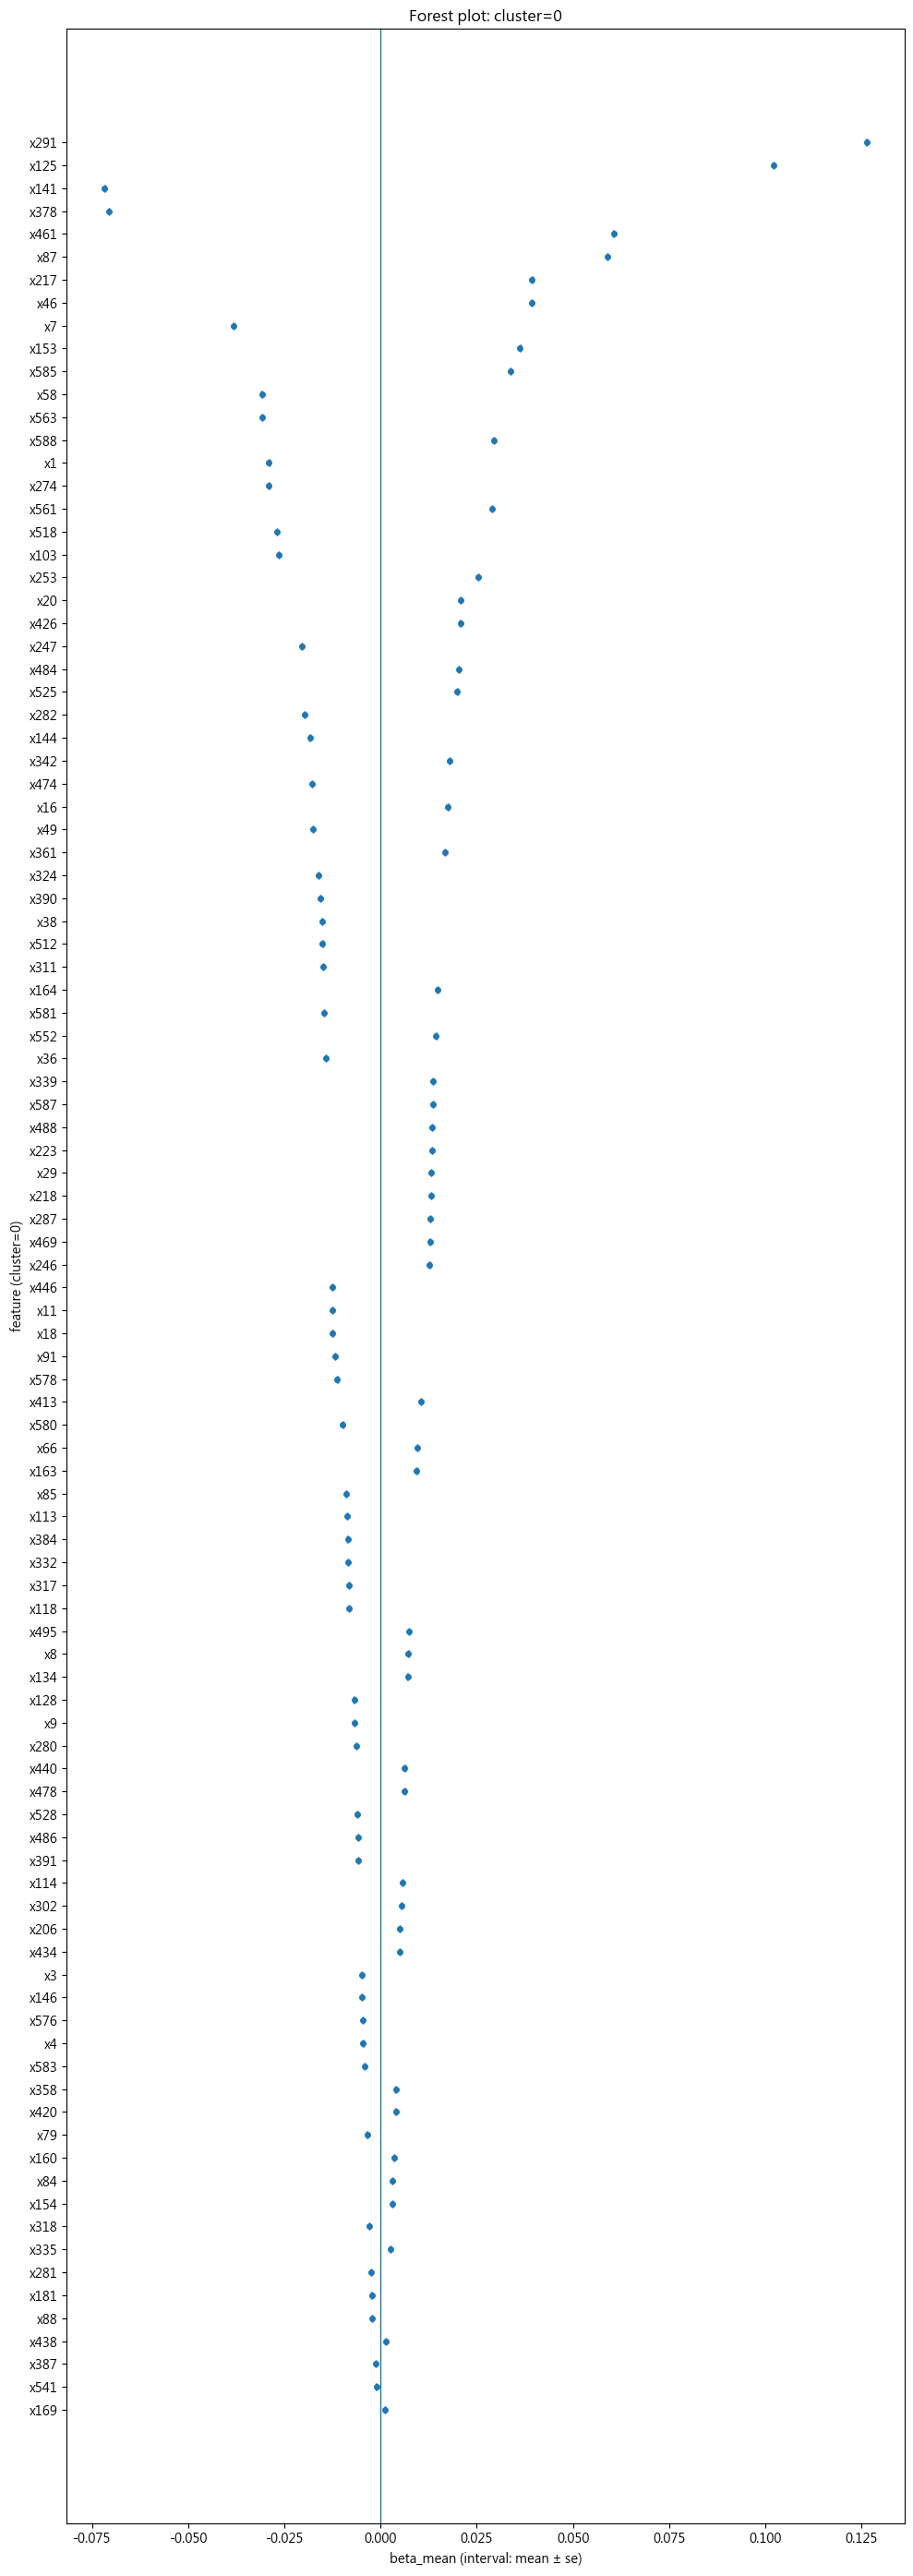

In [8]:
# cluster=0
df0 = df_summary[df_summary["cluster"] == 0].copy()

# 依 |beta_mean| 排序（你也可改成 select_rate / select_count）
df0["abs_beta_mean"] = df0["beta_mean"].abs()
df0 = df0.sort_values("abs_beta_mean", ascending=True).reset_index(drop=True)

# y 位置
y = np.arange(len(df0))

# 區間 [beta_mean - beta_se, beta_mean + beta_se]
x = df0["beta_mean"].to_numpy()
xerr = df0["beta_se"].to_numpy()  # 這會畫成 mean ± se

fig_h = max(4, 0.28 * len(df0))
plt.figure(figsize=(10, fig_h))

plt.errorbar(
    x, y,
    xerr=xerr,
    fmt="o",
    capsize=3,
    linewidth=1,
    markersize=4
)

# 參考線 beta=0
plt.axvline(0, linewidth=1)

# y 軸標籤：feature（需要也可換成 feature_idx）
plt.yticks(y, df0["feature"].astype(str))

plt.xlabel("beta_mean (interval: mean ± se)")
plt.ylabel("feature (cluster=0)")
plt.title("Forest plot: cluster=0")
plt.tight_layout()
plt.show()


In [48]:
df_all_runs.head()

,feature,feature_idx,coef,abs_coef,t,p,r2_model,df_resid,rng_seed,n_block,round_id,threshold,q_used,rank_p,cluster,x0_indices,p_oof_center,p_final_center,run_id
0,x291,238,0.126503,0.126503,544.601845,0.0,0.612732,799540,100042,800000,1,0.01,459,1,0,"[82, 225, 44, 144, 345]",0.498747,0.966755,0
1,x125,115,0.102467,0.102467,440.902893,0.0,0.612732,799540,100042,800000,1,0.01,459,2,0,"[82, 225, 44, 144, 345]",0.498747,0.966755,0
2,x141,131,-0.071653,0.071653,-308.641944,0.0,0.612732,799540,100042,800000,1,0.01,459,3,0,"[82, 225, 44, 144, 345]",0.498747,0.966755,0
3,x378,302,-0.071126,0.071126,-306.410650,0.0,0.612732,799540,100042,800000,1,0.01,459,4,0,"[82, 225, 44, 144, 345]",0.498747,0.966755,0
4,x461,364,0.060817,0.060817,262.180489,0.0,0.612732,799540,100042,800000,1,0.01,459,5,0,"[82, 225, 44, 144, 345]",0.498747,0.966755,0


---
---

In [62]:
# ===== (A) 最小新增：用 final features 在 x0 周圍抽大量格點、分批累積 sufficient stats =====

def local_surrogate_fixed_features_bigN(
    x0,
    blackbox_model,
    block_cols,          # final features indices
    delta,
    k,
    scaler=None,
    n_total=2_000_000,
    rng_seed=0,
    center_first=True,
):
    """
    固定特徵集合 block_cols (=final features)，在 x0 周圍一次抽 n_total 格點，
    以黑箱輸出 y_hat 做目標，對 X_block (=delta*offsets) 做 OLS：
        y_hat ~ [1, X_block]
    """
    x0 = np.asarray(x0, np.float32).reshape(1, -1)

    if scaler is not None:
        x0_scaled = scaler.transform(x0).astype(np.float32, copy=False)
    else:
        x0_scaled = x0.copy()

    p_model = x0_scaled.shape[1]
    block_cols = np.asarray(block_cols, dtype=np.int64)
    q = int(block_cols.size)
    if q < 1:
        raise ValueError("block_cols 至少 1 維")
    if k < 0:
        raise ValueError("k must be >= 0")
    if n_total < 1:
        raise ValueError("n_total must be >= 1")

    rng = np.random.default_rng(int(rng_seed))

    # 1) 一次生成 offsets / X_block（只在 q 維）
    offsets_q = _sample_offsets_block(
        q, k, int(n_total),
        center_first=bool(center_first),
        rng=rng
    )  # (n_total, q) float32
    X_block = (np.float32(delta) * offsets_q).astype(np.float32, copy=False)

    # 2) 一次組出完整 Z（n_total, p_model）再丟黑箱
    Zs = np.empty((int(n_total), p_model), dtype=np.float32)
    Zs[:] = x0_scaled
    Zs[:, block_cols] += X_block

    if scaler is not None:
        Z = scaler.inverse_transform(Zs).astype(np.float32, copy=False)
    else:
        Z = Zs

    if hasattr(blackbox_model, "predict_proba"):
        y = blackbox_model.predict_proba(Z)[:, 1]
    else:
        y = blackbox_model.predict(Z)

    y = np.asarray(y, dtype=np.float32).reshape(-1)
    if y.size != int(n_total):
        raise ValueError("blackbox 輸出長度與 n_total 不一致")
    
    Z_sub = Zs[:, block_cols].astype(np.float64, copy=False)

    # 3) sufficient stats（一次算完）
    Sxx = np.zeros((q + 1, q + 1), dtype=np.float64)
    Sxy = np.zeros((q + 1,), dtype=np.float64)

    Sxx[0, 0] = float(n_total)
    sx = Z_sub.sum(axis=0, dtype=np.float64)
    Sxx[0, 1:] = sx
    Sxx[1:, 0] = sx
    Sxx[1:, 1:] = (Z_sub.T @ Z_sub).astype(np.float64, copy=False)

    sy = float(y.sum(dtype=np.float64))
    Sxy[0] = sy
    Sxy[1:] = (Z_sub.T @ y).astype(np.float64, copy=False)

    Syy = float(y @ y)
    st = _ols_from_sufficient_stats(Sxx, Sxy, Syy, sy, int(n_total), q)

    info = {
        "n": int(n_total),
        "q": int(q),
        "k": int(k),
        "delta": float(delta),
        "block_cols": block_cols.tolist(),
        "intercept": float(st["beta"][0]),
        "coef_block": st["beta"][1:].copy(),
        "se_block": st["se"][1:].copy(),
        "t_block": st["t"][1:].copy(),
        "p_block": st["p"][1:].copy(),
        "intercept_p": float(st["p"][0]) if np.isfinite(st["p"][0]) else np.nan,
        "r2": float(st["r2"]),
        "aic": float(st["aic"]),
        "bic": float(st["bic"]),
        "df_resid": int(st["df_resid"]),
        "rng_seed": int(rng_seed),
    }
    return info

# ===== (B) 最小用法：先拿 final features，再做 200 萬格點的局部回歸 =====
# 這段直接接在你現有流程後面跑

# 1) 用原本流程先得到 df_all_runs, df_summary（你已經有了）
# df_all_runs, df_summary = run_repeat_screening_stats(...)

# 2) 取 cluster=0 的 final features（用 select_rate=1 或 select_count 最大那批；這裡用 select_rate==1）
final_cols_c0 = df_summary.query("cluster==0 and select_rate==1.0")["feature_idx"].to_numpy(dtype=int)

# 3) 取 cluster=0 的中心點 x_center（沿用你原本挑 x0 的方式，最小改：直接重算一次 x_center）
#    注意：這裡用同一套 pick_x0_indices + x_center 定義，與前面一致
c = 0
idx_c = np.where(c_all == c)[0]
p_hat_c = np.asarray(p_hat_oof)[idx_c]
loc = pick_x0_indices(p_hat_c, target=0.5, topk=5)
global_ids = [int(idx_c[pos]) for pos in loc]
x_center_c0 = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

# 4) 用 cluster=0 的最終黑箱模型
m0 = blackbox_by_c[0]

# 5) 抽 200 萬格點做一次 OLS（分批累積）
info_big = local_surrogate_fixed_features_bigN(
    x0=x_center_c0,
    blackbox_model=m0,
    block_cols=final_cols_c0,
    delta=0.1,
    k=2,
    scaler=None,           # 你現在黑箱吃的是標準化空間
    n_total=2_000_000,
    rng_seed=123,          # 固定即可重現
    center_first=True,
)

# 6) 整理成一張表（係數、p-value、含 intercept）
feature_names = list(X_all_df.columns)
rows = [{
    "feature": "(intercept)",
    "feature_idx": -1,
    "coef": float(info_big["intercept"]),
    "se": np.nan,
    "t": np.nan,
    "p": float(info_big["intercept_p"]),
    "r2": float(info_big["r2"])
}]
for t, col in enumerate(final_cols_c0):
    rows.append({
        "feature": feature_names[int(col)],
        "feature_idx": int(col),
        "coef": float(info_big["coef_block"][t]),
        "se": float(info_big["se_block"][t]),
        "t": float(info_big["t_block"][t]),
        "p": float(info_big["p_block"][t]),
        "r2": float(info_big["r2"]),
    })

df_local_final = pd.DataFrame(rows).sort_values(["p"], ascending=True).reset_index(drop=True)

# df_local_final 就是：在 x_center_c0 周圍、只用 final features、抽 200 萬格點擬合出的局部線性模型
# 線性函數（標準化空間位移版本）：
#   y_hat ≈ intercept + Σ coef_j * (x_j - x0_j)   （此處 x_j 指標準化座標；(x_j-x0_j) 就是 X_block）


In [64]:
df_local_final[['feature', 'coef', 'p']].head(30)

,feature,coef,p
0,(intercept),1.164411,0.0
1,x11,-0.012369,0.0
2,x18,-0.012340,0.0
3,x91,-0.012102,0.0
4,x578,-0.011193,0.0
5,x580,-0.009745,0.0
6,x85,-0.008851,0.0
7,x113,-0.008834,0.0
8,x446,-0.012711,0.0
9,x384,-0.008593,0.0


In [65]:
df_local_final.to_csv('df_local_final_c=0', sep='\t')

In [66]:
# 1) 用原本流程先得到 df_all_runs, df_summary（你已經有了）
# df_all_runs, df_summary = run_repeat_screening_stats(...)

# 2) 取 cluster=0 的 final features（用 select_rate=1 或 select_count 最大那批；這裡用 select_rate==1）
final_cols_c1 = df_summary.query("cluster==1 and select_rate==1.0")["feature_idx"].to_numpy(dtype=int)

# 3) 取 cluster=0 的中心點 x_center（沿用你原本挑 x0 的方式，最小改：直接重算一次 x_center）
#    注意：這裡用同一套 pick_x0_indices + x_center 定義，與前面一致
c = 1
idx_c = np.where(c_all == c)[0]
p_hat_c = np.asarray(p_hat_oof)[idx_c]
loc = pick_x0_indices(p_hat_c, target=0.5, topk=5)
global_ids = [int(idx_c[pos]) for pos in loc]
x_center_c1 = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

# 4) 用 cluster=0 的最終黑箱模型
m1 = blackbox_by_c[1]

# 5) 抽 200 萬格點做一次 OLS（分批累積）
info_big = local_surrogate_fixed_features_bigN(
    x0=x_center_c1,
    blackbox_model=m1,
    block_cols=final_cols_c1,
    delta=0.1,
    k=2,
    scaler=None,           # 你現在黑箱吃的是標準化空間
    n_total=2_000_000,
    rng_seed=123,          # 固定即可重現
    center_first=True,
)

# 6) 整理成一張表（係數、p-value、含 intercept）
feature_names = list(X_all_df.columns)
rows = [{
    "feature": "(intercept)",
    "feature_idx": -1,
    "coef": float(info_big["intercept"]),
    "se": np.nan,
    "t": np.nan,
    "p": float(info_big["intercept_p"]),
    "r2": float(info_big["r2"])
}]
for t, col in enumerate(final_cols_c1):
    rows.append({
        "feature": feature_names[int(col)],
        "feature_idx": int(col),
        "coef": float(info_big["coef_block"][t]),
        "se": float(info_big["se_block"][t]),
        "t": float(info_big["t_block"][t]),
        "p": float(info_big["p_block"][t]),
        "r2": float(info_big["r2"]),
    })

df_local_final = pd.DataFrame(rows).sort_values(["p"], ascending=True).reset_index(drop=True)

# df_local_final 就是：在 x_center_c0 周圍、只用 final features、抽 200 萬格點擬合出的局部線性模型
# 線性函數（標準化空間位移版本）：
#   y_hat ≈ intercept + Σ coef_j * (x_j - x0_j)   （此處 x_j 指標準化座標；(x_j-x0_j) 就是 X_block）


In [68]:
df_local_final.to_csv('df_local_final_c=1', sep='\t')

---
---

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\No\AppData\Local\Temp\ipykernel_15372\2790406344.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


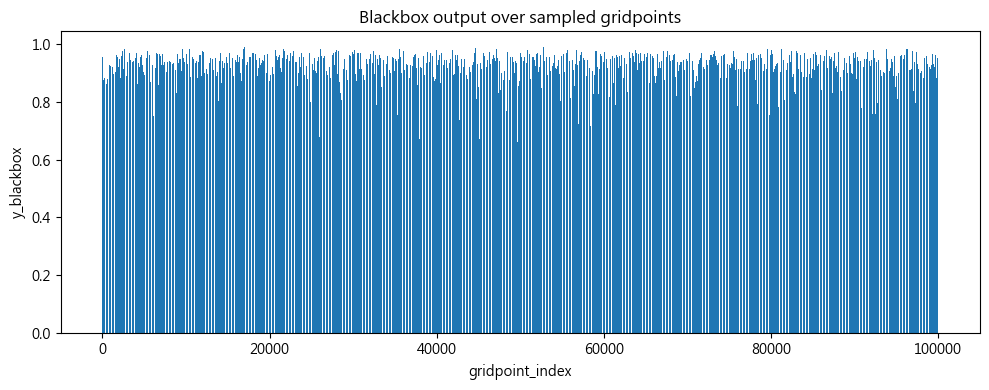

In [52]:
def preview_gridpoints_first_n(
    x0,
    blackbox_model,
    feature_names,
    delta,
    k,
    scaler=None,
    n_preview=30,
    rng_seed=0,
):
    """
    只做兩件事：
    1) 在 x0 附近抽樣 n_preview 個格子點（第一筆為中心點）
    2) 丟進 blackbox 得到 y_blackbox
    回傳：df_preview（n_preview 列，所有特徵欄 + y_blackbox）
    """
    x0 = np.asarray(x0, np.float32).reshape(1, -1)

    # x0 若在標準化空間，這裡保持一致（你目前 x0 來自 X_all_df，已是標準化空間）
    if scaler is not None:
        x0_scaled = scaler.transform(x0).astype(np.float32, copy=False)
    else:
        x0_scaled = x0.copy()

    p_model = x0_scaled.shape[1]
    feature_names = list(feature_names)
    if len(feature_names) != p_model:
        raise ValueError("feature_names 長度需等於 x0 維度")

    rng = np.random.default_rng(rng_seed)

    # 產生 offsets（n_preview, p_model）
    offsets = rng.integers(-k, k + 1, size=(n_preview, p_model), dtype=np.int16).astype(np.float32)
    if n_preview > 0:
        offsets[0, :] = 0.0  # 第一筆中心點

    # 標準化空間的格子點
    Zs = np.empty((n_preview, p_model), dtype=np.float32)
    Zs[:] = x0_scaled
    Zs += (np.float32(delta) * offsets).astype(np.float32, copy=False)

    # 回到原始特徵尺度（如果你傳入 scaler）
    if scaler is not None:
        Z = scaler.inverse_transform(Zs).astype(np.float32, copy=False)
    else:
        Z = Zs

    # 黑箱輸出
    if hasattr(blackbox_model, "predict_proba"):
        yb = blackbox_model.predict_proba(Z)[:, 1]
    else:
        yb = blackbox_model.predict(Z)

    yb = np.asarray(yb, dtype=np.float32).reshape(-1)
    if yb.size != n_preview:
        raise ValueError("blackbox 輸出長度與 n_preview 不一致")

    df_preview = pd.DataFrame(Z, columns=feature_names)
    df_preview["y_blackbox"] = yb
    return df_preview

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=1e-7, rtol=1e-7)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    """
    以分群為單位做 StratifiedKFold OOF，回傳每筆真實點的 OOF 機率 p_oof。
    每個 fold 的 training 內部再做 SMOTE，避免合成點寫回 OOF。
    """
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all, random_state=42):
    """
    以分群為單位訓練最終 blackbox（群內先 SMOTE 再 fit），回傳 dict{cluster: model}。
    """
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
        Xc_sm, yc_sm = sm.fit_resample(Xc, yc)

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc_sm, yc_sm)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)

def pick_x0_indices(p, target, topk=5, min_p=None):
    """
    依 |p - target| 選出最接近 target 的 topk 索引（可加 min_p 過濾）。
    """
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]
# ====== 選一個 cluster，挑 x0（中心點）=====
c = 0
idx_c = np.where(c_all == c)[0]
p_hat_c = np.asarray(p_hat_oof)[idx_c]

loc = pick_x0_indices(p_hat_c, target=0.5, topk=5)
global_ids = [int(idx_c[pos]) for pos in loc]
x_center = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

# ====== 只列前 30 筆格子點所有 x + 黑箱 y ======
df_preview = preview_gridpoints_first_n(
    x0=x_center,
    blackbox_model=blackbox_by_c[c],
    feature_names=X_all_df.columns,
    delta=0.1,
    k=2,
    scaler=None,        # 你這裡資料已在標準化空間，維持 None
    n_preview=100_000,
    rng_seed=42,
)

# df_preview

# 用格點生成順序當 x 軸
y = df_preview["y_blackbox"].to_numpy()
x = np.arange(len(y))

plt.figure(figsize=(10, 4))
plt.bar(x, y)
plt.xlabel("gridpoint_index")
plt.ylabel("y_blackbox")
plt.title("Blackbox output over sampled gridpoints")
plt.tight_layout()
plt.show()

In [53]:
df_preview

,x1,x2,x3,x4,x5,x7,x8,x9,x10,x11,...,x582,x583,x584,x585,x586,x587,x588,x589,x590,y_blackbox
0,-0.328949,-0.511108,0.610926,0.03072,-0.0561,0.12279,-0.025324,0.288846,0.45722,0.51825,...,0.041253,0.632542,-0.118409,-0.107773,-0.117483,-0.372303,-0.088437,0.098306,0.023303,0.966755
1,-0.528949,-0.411108,0.610926,-0.16928,0.1439,0.12279,-0.225324,0.188846,0.55722,0.61825,...,0.041253,0.632542,-0.118409,0.092227,-0.317483,-0.572303,0.011563,-0.001694,0.223303,0.940804
2,-0.528949,-0.711108,0.710926,0.13072,-0.1561,-0.07721,-0.225324,0.388846,0.25722,0.51825,...,0.041253,0.432542,-0.018409,0.092227,-0.017483,-0.372303,-0.088437,0.098306,0.123303,0.983204
3,-0.328949,-0.711108,0.710926,-0.16928,0.1439,0.22279,0.074676,0.188846,0.65722,0.71825,...,0.241253,0.832542,-0.118409,-0.207773,-0.117483,-0.172303,-0.088437,0.098306,0.123303,0.889116
4,-0.228949,-0.611108,0.710926,0.13072,0.0439,0.32279,0.074676,0.288846,0.45722,0.51825,...,0.141253,0.832542,-0.118409,-0.207773,0.082517,-0.372303,-0.088437,0.098306,0.123303,0.881310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-0.128949,-0.311108,0.810926,0.23072,-0.0561,0.32279,-0.025324,0.188846,0.45722,0.51825,...,0.041253,0.532542,-0.018409,-0.107773,0.082517,-0.572303,0.011563,-0.001694,-0.076697,0.877284
99996,-0.328949,-0.611108,0.810926,0.13072,-0.1561,0.22279,0.074676,0.288846,0.55722,0.31825,...,0.041253,0.832542,-0.018409,-0.107773,-0.217483,-0.572303,0.011563,-0.101694,-0.076697,0.927624
99997,-0.328949,-0.411108,0.810926,-0.06928,-0.1561,-0.07721,0.074676,0.488846,0.25722,0.51825,...,-0.058747,0.832542,-0.018409,-0.007773,-0.117483,-0.572303,-0.188437,-0.001694,0.023303,0.969534
99998,-0.528949,-0.711108,0.710926,0.03072,-0.0561,0.32279,-0.125324,0.388846,0.45722,0.41825,...,-0.158747,0.432542,-0.018409,-0.007773,-0.317483,-0.572303,-0.188437,0.298306,0.023303,0.925753


In [ ]:
def pick_test_points_near_half_per_cluster(
    X_all_df, y_all, c_all,
    n_splits=5, random_state=42,
    tol=0.01,          # |p-0.5| <= tol
    topk=None,         # 若不想用 tol，改用每個 fold 取 topk 個最接近 0.5
):
    """
    回傳 df_sel：
    每筆為一個「testing fold」上的樣本點，
    欄位包含：cluster, fold_id, global_idx, p_test, y_true, (所有 x 特徵)
    """
    y_all = np.asarray(y_all).astype(int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    rows = []

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]              # global indices in this cluster
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        fold_id = 0
        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]
            te_global = idx[te]                    # map back to global indices

            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr_sm, y_tr_sm)

            p_te = m.predict_proba(X_te)[:, 1]
            dist = np.abs(p_te - 0.5)

            if topk is not None:
                pick = np.argsort(dist)[:min(int(topk), len(te))]
            else:
                pick = np.where(dist <= tol)[0]

            if pick.size > 0:
                picked_global = te_global[pick]
                X_pick = X_all_df.iloc[picked_global].copy()
                X_pick["y_true"] = y_all[picked_global]
                X_pick["p_test"] = p_te[pick]
                X_pick["global_idx"] = picked_global
                X_pick["cluster"] = int(c)
                X_pick["fold_id"] = int(fold_id)
                rows.append(X_pick)

            fold_id += 1

    df_sel = pd.concat(rows, ignore_index=True) if len(rows) else pd.DataFrame()
    if len(df_sel):
        # 讓欄位順序清楚：meta 在前，特徵在後
        meta_cols = ["cluster", "fold_id", "global_idx", "p_test", "y_true"]
        feat_cols = [c for c in df_sel.columns if c not in meta_cols]
        df_sel = df_sel[meta_cols + feat_cols].sort_values(
            ["cluster", "fold_id", "p_test"], ascending=[True, True, True]
        ).reset_index(drop=True)
    return df_sel

df_half = pick_test_points_near_half_per_cluster(
    X_all_df=X_all_df,
    y_all=y_real,
    c_all=c_all,
    n_splits=5,
    random_state=42,
    tol=0.01,
    topk=5
)

df_half



,cluster,fold_id,global_idx,p_test,y_true,x1,x2,x3,x4,x5,...,x581,x582,x583,x584,x585,x586,x587,x588,x589,x590
0,0,0,164,0.420347,0,0.124656,0.323974,-0.296289,-0.603230,-0.051625,...,0.196786,-0.143228,-1.910852,0.781844,0.705522,0.771321,-0.831673,0.308518,0.188662,0.764557
1,0,0,653,0.548375,0,0.147121,-2.252838,-0.725465,-1.184631,-0.053558,...,-0.674082,-0.324392,-0.497855,-0.213960,-0.091826,-0.203549,-0.493190,-0.576124,-0.436879,-0.270221
2,0,0,292,0.570125,0,-3.078105,1.107517,0.801839,0.246799,-0.048457,...,-0.203213,-0.356339,0.591330,-0.352107,-0.304452,-0.339926,-0.871969,-1.052470,-0.958164,-0.348680
3,0,0,211,0.576047,0,-0.754324,-0.045192,-0.658799,-0.880132,-0.051795,...,-0.126554,-0.137693,0.473580,-0.150643,-0.171561,-0.148473,-0.493190,1.215843,1.787268,0.824068
4,0,0,236,0.579679,0,-0.596392,1.439193,-0.500082,-0.914652,-0.051790,...,1.974126,1.404492,0.620767,-0.323326,-0.357609,-0.313397,-0.404540,1.385966,1.474497,0.796333
5,0,1,195,0.364440,0,-0.303399,-0.312476,-0.096666,-0.346796,-0.062067,...,-0.914828,-0.571383,1.356703,-0.346350,-0.144983,-0.336472,-0.009643,-0.417343,-0.610641,-0.422590
6,0,1,368,0.381138,0,-0.857717,-0.672674,0.055990,-0.826250,-0.062252,...,-0.433336,-0.511473,0.650205,-0.196692,-0.118405,-0.194153,0.030653,-0.292585,-0.263118,-0.385631
7,0,1,359,0.436062,0,-1.229744,0.884199,0.452591,-0.647994,-0.063206,...,1.125711,0.643348,-0.409543,0.666722,0.519474,0.643483,-0.896146,-0.916371,-0.992916,-0.204351
8,0,1,111,0.457258,0,0.074718,-0.216323,1.423820,0.665684,-0.050910,...,-0.027160,-0.219108,0.032019,-0.087326,-0.224718,-0.084913,-1.266866,0.059003,0.258167,2.041247
9,0,1,284,0.585583,0,-1.748741,1.002397,0.616988,0.522543,-0.061134,...,-0.144440,7.235834,-0.203481,0.862429,0.678943,0.827835,-1.476403,0.002295,-0.054604,4.393704


In [31]:
df_half[df_half['cluster']==0].assign(dist=lambda d: (d["p_test"] - 0.5).abs()).sort_values(["dist", "p_test"], ascending=[True, True]).head(5)

,cluster,fold_id,global_idx,p_test,y_true,x1,x2,x3,x4,x5,...,x582,x583,x584,x585,x586,x587,x588,x589,x590,dist
11,0,2,82,0.498364,0,-0.921323,-0.263777,0.689715,-0.757926,-0.058760,...,0.393940,-0.497855,0.154430,0.014487,0.149015,-0.170825,0.671448,1.057470,0.172921,0.001636
12,0,2,225,0.516134,0,0.794818,-1.815294,1.487459,0.622868,-0.059727,...,0.271142,0.503018,-0.277277,-0.171561,-0.270646,-0.646313,-0.564783,-0.332622,-0.154877,0.016134
16,0,3,44,0.481022,0,0.367305,2.479558,0.205618,-0.353291,-0.053588,...,0.267953,1.121204,-0.213960,-0.224718,-0.210375,-0.114411,0.592057,0.779451,0.095199,0.018978
13,0,2,144,0.527558,0,-1.446410,-0.375622,0.731760,0.340708,-0.049010,...,-0.771852,1.297828,-0.334838,-0.357609,-0.326247,0.199895,-0.553441,-0.610641,-0.546260,0.027558
22,0,4,345,0.470658,0,-0.439136,-2.580404,-0.059922,0.301241,-0.059416,...,0.045082,0.738517,0.079600,0.200535,0.070836,-1.129861,-0.587466,-0.402127,0.549533,0.029342


In [35]:
# 你指定的五個點（cluster=0）
ids = [82, 225, 44, 144, 345]

# 想展示的特徵欄（把這裡換成你要放進論文的那幾個 feature 名稱）
show_feats = ["x1", "x2", "x3", 'x588',"x589", 'x590']  # 範例

# 取出這五點的 y_true 與 p_test（p_test 來自 df_half）
df_pts = (
    df_half[df_half["global_idx"].isin(ids) & (df_half["cluster"] == 0)]
    .drop_duplicates(subset=["global_idx"])   # 避免同一點在不同 fold 重複被收進來時造成重複列
    .set_index("global_idx")
    .loc[ids]                                  # 依你指定順序排
    .reset_index()
)

# 合併 x（X_all_df）與 y_true（y_real），並挑出要展示的欄位
df_tbl = X_all_df.loc[ids, show_feats].copy()
df_tbl["y_true"] = y_real[ids]
df_tbl = df_tbl.reset_index().rename(columns={"index": "global_idx"})

# 把 p_test 併回去
df_tbl = df_tbl.merge(df_pts[["global_idx", "p_test"]], on="global_idx", how="left")

df_tbl


,global_idx,x1,x2,x3,x588,x589,x590,y_true,p_test
0,82,-0.921323,-0.263777,0.689715,0.671448,1.057470,0.172921,0,0.498364
1,225,0.794818,-1.815294,1.487459,-0.564783,-0.332622,-0.154877,0,0.516134
2,44,0.367305,2.479558,0.205618,0.592057,0.779451,0.095199,0,0.481022
3,144,-1.446410,-0.375622,0.731760,-0.553441,-0.610641,-0.546260,0,0.527558
4,345,-0.439136,-2.580404,-0.059922,-0.587466,-0.402127,0.549533,0,0.470658
